lens_pos (abs)      : [62. 62. 62. 67. 67. 67. 70. 70. 70. 60. 60. 60. 65. 65. 65.]
screen_pos (abs)    : [ 93.2  93.   93.5  86.2  86.   87.   86.9  87.6  86.7 114.5 111.4 111.5
  86.7  89.5  87.6]
u (lens - object) cm: [ 5.  5.  5. 10. 10. 10. 13. 13. 13.  3.  3.  3.  8.  8.  8.]
v (screen - lens) cm: [31.2 31.  31.5 19.2 19.  20.  16.9 17.6 16.7 54.5 51.4 51.5 21.7 24.5
 22.6]

=== Distance-only linear fit (1/u vs 1/v) ===
Measured slope = -0.1473 (ideal = -1)
Intercept = 0.065612  => f = 15.2410 cm
R^2 = 0.9368

=== Proper chi-squared fit (distances + magnification) ===
Best-fit focal length f = 4.8087 ± 5.9733 cm
Chi^2 = 338.2879, dof = 29, Reduced Chi^2 = 11.6651


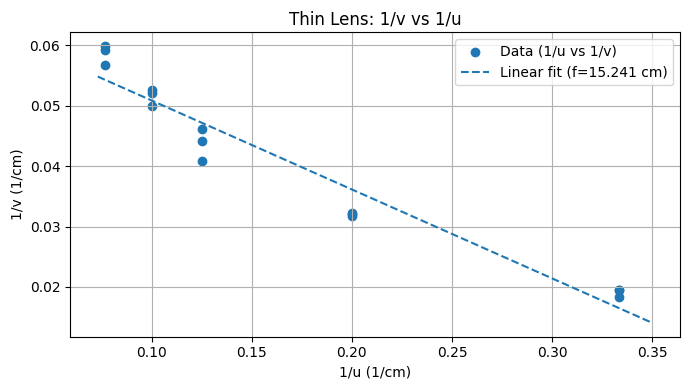

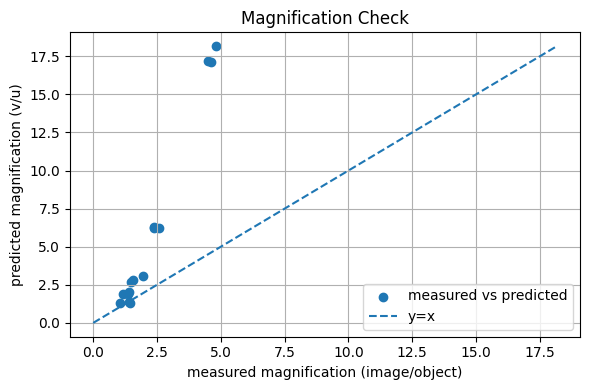

In [69]:
import numpy as np
from scipy.optimize import minimize
from scipy.stats import linregress
import matplotlib.pyplot as plt

# -------------------------------
# Data parsed from your table
# -------------------------------
data = {
    62.0: [(93.2, 25.63), (93.0, 23.93), (93.5, 23.76)],
    67.0: [(86.2, 11.49), (86.0, 13.67), (87.0, 13.93)],
    70.0: [(86.9, 10.56), (87.6, 14.11), (86.7, 14.39)],
    60.0: [(114.5, 48.19), (111.4, 46.12), (111.5, 45.16)],
    65.0: [(86.7, 14.66), (89.5, 19.37), (87.6, 15.67)],
}

# -------------------------------
# User / experiment settings
# -------------------------------
object_pos_cm = 57.0    # absolute object position (cm)
object_size_mm = 10.0   # object diameter (mm) -- set to None if unknown

# -------------------------------
# Build arrays from data
# -------------------------------
lens_pos_list = []
screen_pos_list = []
img_size_mm_list = []

for lens_pos, trials in data.items():
    for screen_pos, img_size in trials:
        lens_pos_list.append(lens_pos)
        screen_pos_list.append(screen_pos)
        img_size_mm_list.append(img_size)

lens_pos = np.array(lens_pos_list)       # cm (absolute)
screen_pos = np.array(screen_pos_list)   # cm (absolute)
img_size_mm = np.array(img_size_mm_list) # mm

# -------------------------------
# Compute u and v
# -------------------------------
u_vals = lens_pos - object_pos_cm   # object -> lens
v_vals = screen_pos - lens_pos      # lens -> image

print("lens_pos (abs)      :", lens_pos)
print("screen_pos (abs)    :", screen_pos)
print("u (lens - object) cm:", u_vals)
print("v (screen - lens) cm:", v_vals)

# -------------------------------
# Linear fit: 1/v vs 1/u
# -------------------------------
valid_idx = np.where((u_vals != 0) & (v_vals != 0))[0]
x = 1.0 / u_vals[valid_idx]
y = 1.0 / v_vals[valid_idx]

slope, intercept, r_value, p_value, stderr = linregress(x, y)
f_from_linear = 1.0 / intercept

print("\n=== Distance-only linear fit (1/u vs 1/v) ===")
print(f"Measured slope = {slope:.4f} (ideal = -1)")
print(f"Intercept = {intercept:.6f}  => f = {f_from_linear:.4f} cm")
print(f"R^2 = {r_value**2:.4f}")

# -------------------------------
# Proper chi-squared function
# -------------------------------
def chi2_params(params, return_full=False):
    f = params[0]
    if f <= 0:
        return 1e12

    # Model prediction: thin lens
    model_y = -1.0 / u_vals + 1.0 / f
    resid_y = (1.0 / v_vals) - model_y

    sigma_y = np.ones_like(resid_y)  # assume equal weight
    chi_y = np.sum((resid_y / sigma_y) ** 2)

    chi_m = 0.0
    N_m = 0
    if object_size_mm is not None:
        m_meas = img_size_mm / object_size_mm
        m_pred = v_vals / u_vals
        sigma_m = np.std(m_meas) if np.std(m_meas) > 0 else 1.0
        resid_m = (m_meas - m_pred) / sigma_m
        chi_m = np.sum(resid_m**2)
        N_m = len(resid_m)

    chi2_total = chi_y + chi_m
    N_total = len(resid_y) + N_m
    dof = N_total - 1  # one parameter f

    if return_full:
        return chi2_total, dof
    else:
        return chi2_total / dof  # reduced chi^2

# -------------------------------
# Minimization
# -------------------------------
res = minimize(lambda p: chi2_params(p), x0=[f_from_linear], bounds=[(1e-3, 1000)])

if res.success:
    f_fit = res.x[0]
    chi2_val, dof = chi2_params([f_fit], return_full=True)
    red_chi2 = chi2_val / dof

    # Estimate uncertainty on f (Hessian approx)
    eps = 1e-4
    f_plus = f_fit + eps
    f_minus = f_fit - eps
    chi_plus = chi2_params([f_plus], return_full=True)[0]
    chi_minus = chi2_params([f_minus], return_full=True)[0]
    second_deriv = (chi_plus - 2*chi2_val + chi_minus) / (eps**2)
    sigma_f = np.sqrt(2 / second_deriv) if second_deriv > 0 else np.nan

    print("\n=== Proper chi-squared fit (distances + magnification) ===")
    print(f"Best-fit focal length f = {f_fit:.4f} ± {sigma_f:.4f} cm")
    print(f"Chi^2 = {chi2_val:.4f}, dof = {dof}, Reduced Chi^2 = {red_chi2:.4f}")
else:
    print("\nChi-squared fit failed:", res.message)

# -------------------------------
# Plotting: 1/u vs 1/v and linear fit
# -------------------------------
plt.figure(figsize=(7,4))
plt.scatter(x, y, label='Data (1/u vs 1/v)')
xs = np.linspace(np.min(x)*0.95, np.max(x)*1.05, 300)
ys = slope*xs + intercept
plt.plot(xs, ys, label=f'Linear fit (f={f_from_linear:.3f} cm)', linestyle='--')
plt.xlabel('1/u (1/cm)')
plt.ylabel('1/v (1/cm)')
plt.title('Thin Lens: 1/v vs 1/u')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# -------------------------------
# Optional: measured vs predicted magnification
# -------------------------------
if object_size_mm is not None:
    m_meas = img_size_mm / object_size_mm
    f_used = f_fit if (res.success and 'f_fit' in locals()) else f_from_linear
    m_pred = v_vals / u_vals
    plt.figure(figsize=(6,4))
    plt.scatter(m_meas, m_pred, label='measured vs predicted')
    maxval = max(np.nanmax(m_meas), np.nanmax(m_pred))
    plt.plot([0, maxval], [0, maxval], linestyle='--', label='y=x')
    plt.xlabel('measured magnification (image/object)')
    plt.ylabel('predicted magnification (v/u)')
    plt.title('Magnification Check')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [68]:
import numpy as np
from scipy.optimize import minimize
from scipy.stats import chi2

# --- Example: assign uncertainties ---
sigma_v = 0.5   # cm uncertainty in screen position (you should set realistically!)
sigma_m = 1.0   # unitless relative uncertainty in magnification (if object size known)

# --- Chi-squared function ---
def chi2_params(params):
    f = params[0]
    if f <= 0:
        return 1e12

    # Predicted lens equation relation
    model_y = -1.0 / u_vals + 1.0 / f
    resid_y = (1.0 / v_vals) - model_y
    # Scale by uncertainty in 1/v (propagate sigma_v)
    sigma_y = sigma_v / (v_vals**2)  # since y=1/v
    chi_y = np.sum((resid_y / sigma_y) ** 2)

    chi_m = 0.0
    if object_size_mm is not None:
        m_meas = img_size_mm / object_size_mm
        m_pred = v_vals / u_vals
        chi_m = np.sum(((m_meas - m_pred) / sigma_m) ** 2)

    return chi_y + chi_m

# --- Fit focal length ---
res = minimize(chi2_params, x0=[f_from_linear], bounds=[(1e-3, 1000)])
if res.success:
    f_fit = res.x[0]
    chi2_val = chi2_params([f_fit])
    N = len(u_vals) + (len(u_vals) if object_size_mm else 0)  # total number of residuals
    p = 1  # number of fitted parameters (f)
    dof = N - p
    red_chi2 = chi2_val / dof
    p_value = chi2.sf(chi2_val, dof)

    print("\n=== Combined fit (distances + magnification) ===")
    print(f"Best-fit focal length f = {f_fit:.4f} cm")
    print(f"Chi-squared = {chi2_val:.3f}")
    print(f"Degrees of freedom = {dof}")
    print(f"Reduced chi-squared = {red_chi2:.3f}")
    print(f"p-value = {p_value:.3f}")
else:
    print("\nCombined fit failed:", res.message)


=== Combined fit (distances + magnification) ===
Best-fit focal length f = 3.0410 cm
Chi-squared = 336946.733
Degrees of freedom = 29
Reduced chi-squared = 11618.853
p-value = 0.000
